## Homework 1: Gradient Descent

### Exercise 3: GD in 2D


In [44]:
import numpy as np
import matplotlib.pyplot as plt

In [45]:
A = np.diag([1.0, 25.0])

In [ ]:
def L(theta):
    return 0.5 * (theta.T @ A @ theta)

def grad_L(theta):
    return A @ theta

def gradient_descent(theta_0, eta, maxit, tolL, toltheta):
    theta = theta_0.astype(float).copy()
    thetas = [theta.copy()]
    losses = [L(theta)]

    for _ in range(maxit):
        g = grad_L(theta)

        # Stop if gradient is small (near optimum)
        if np.linalg.norm(g) < tolL:
            break

        theta_next = theta - eta * g

        # Stop if update is very small
        if np.linalg.norm(theta_next - theta) < toltheta:
            theta = theta_next
            thetas.append(theta.copy())
            losses.append(L(theta))
            break

        theta = theta_next
        thetas.append(theta.copy())
        losses.append(L(theta))

    return theta, thetas, losses

In [47]:
def quad_levelsets(A, xlim=(-3,3), ylim=(-3,3), ngrid=400, ncontours=12, title=None):
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)
    X, Y = np.meshgrid(xs, ys)

    Z = 0.5 * (A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2)

    cs = plt.contour(X, Y, Z, levels=ncontours)
    plt.clabel(cs, inline=True, fontsize=8)

    plt.axhline(0, lw=0.5, color='k')
    plt.axvline(0, lw=0.5, color='k')
    plt.gca().set_aspect('equal', 'box')

    if title:
        plt.title(title)

    plt.xlabel(r'$\theta_1$')
    plt.ylabel(r'$\theta_2$')
    plt.grid(alpha=0.2)
    plt.ylim(ylim)
    plt.xlim(xlim)
        
def show_sets(eta, theta_0, maxit=60, tolL=1e-10, toltheta=1e-12):
    sol_theta, thetas, losses = gradient_descent(theta_0, eta, maxit, tolL, toltheta)

    plt.figure(figsize=(7,6))

    quad_levelsets(A, xlim=(-4,4), ylim=(-4,4), ncontours=15,
                   title=f'Level sets + GD iterates (eta={eta})')

    c1 = np.array([0.7, 0.7, 1.0])   # light blue
    c2 = np.array([0.0, 0.0, 0.8])   # darker blue
    colors = [c1 + (c2 - c1) * t for t in np.linspace(0, 1, len(thetas))]

    thetas = np.array(thetas)

    # Overlay path + points
    plt.plot(thetas[:,0], thetas[:,1], linewidth=0.75, zorder=1)
    plt.scatter(thetas[:,0], thetas[:,1], c=colors, s=15, zorder=2, label="successive thetas")

    # Mark solution (optimum is (0,0); GD should go there if it converges)
    plt.scatter(sol_theta[0], sol_theta[1], c="red", s=30, zorder=3,
                label=f"last iterate ({sol_theta[0]:.2f}, {sol_theta[1]:.2f})")

    plt.legend()
    plt.tight_layout()

    print(f"\nη = {eta}")
    print(f"iterations used = {len(thetas)-1}")
    print(f"theta_last = {sol_theta}")
    print(f"L(theta_last) = {losses[-1]}")
    
    plt.show()



η = 0.02
iterations used = 100
theta_last = [-2.65239112e-01  1.57772181e-30]
L(theta_last) = 0.03517589321144311


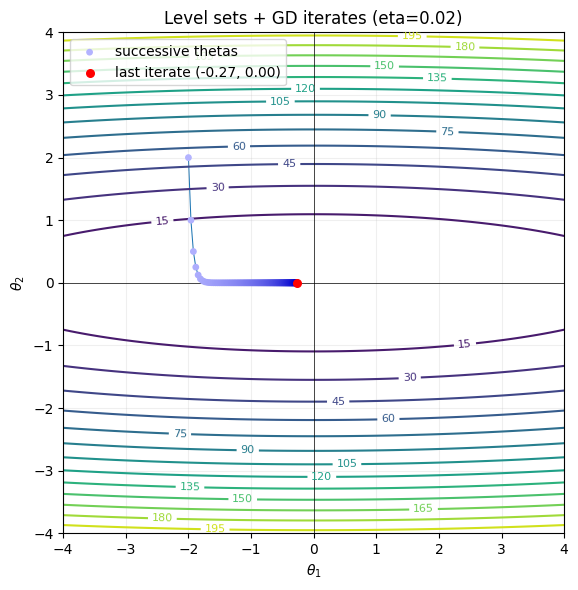


η = 0.05
iterations used = 100
theta_last = [-1.18410584e-02  1.24460306e-60]
L(theta_last) = 7.010533249765804e-05


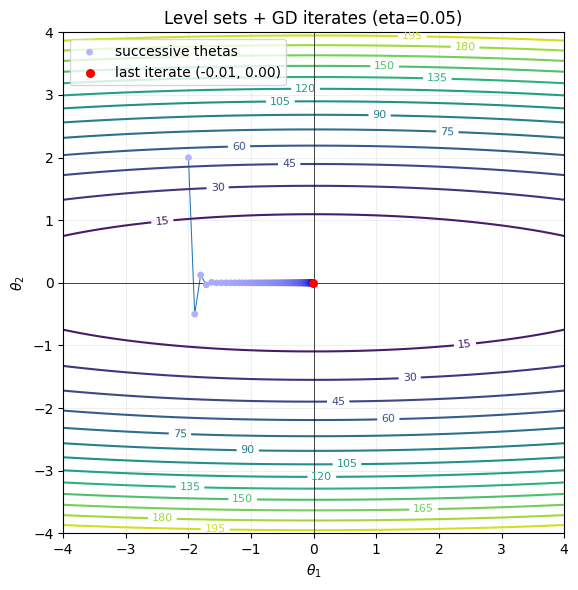


η = 0.1
iterations used = 10
theta_last = [ -0.69735688 115.33007812]
L(theta_last) = 166263.07965729173


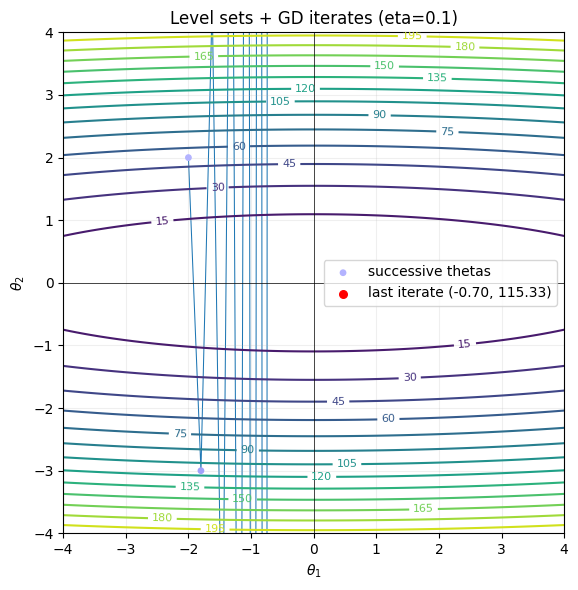

In [48]:
theta_0 = np.array([-2, 2])

for eta in [0.02, 0.05, 0.1]:
    if eta is not 0.1:
        maxit = 100
    else:
        maxit = 10
    show_sets(eta, theta_0, maxit=maxit, tolL=1e-10, toltheta=1e-12)